<a href="https://colab.research.google.com/github/TamannaThakker/assignment2/blob/main/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# do not show output to prevent it on html file
%%capture
from google.colab import drive
drive.mount("/content/drive" )

In [14]:
import os, sys
# os.listdir('/content/drive/MyDrive/Colab Notebooks')

In [15]:
import os, sys
if 'google.colab' in sys.modules:
    DRIVE_PATH="/content/drive/MyDrive/Colab Notebooks"
    os.chdir(DRIVE_PATH)
    # print(f'Working directory set to: {DRIVE_PATH}')


# Child Mortality and Immunisation: A Global Look

Every year, millions of children die before they even turn five. Most of these deaths happen in third world countries, from diseases and conditions that can be prevented. What makes it a frustrating issue is that fact that a solution exists however is not reachable to all.

This report uses UNICEF data to look at **infant mortality** (deaths in the first year of life per 1,000 births) and **polio vaccination rates** around the world. The main questions that were addressed are:

- Where are children most at risk?
- Has the situation improved over time?
- Is there a link between a country's wealth and infant survival?
- Which countries are still not vaccinating enough children?

Although things have improved globally, but the gap between rich and poor countries is still very wide.

In [16]:
#| label: setup
#| include: false

import polars as pl
import pandas as pd
import geopandas as gpd
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Load UNICEF datasets
indicator1 = pl.read_csv('unicef_indicator_1.csv')
indicator2 = pl.read_csv('unicef_indicator_2.csv')
metadata   = pl.read_csv('unicef_metadata.csv')

## 1. Where Is Infant Mortality the Highest?

The map below gives a birds eye view of how infant mortality is spread across the world. Darker red means more deaths per 1,000 live births, lighter red means fewer, and grey means no data was available.

What stood out the most is where the concentration of the problem lies. **Sub-Saharan Africa** has the darkest colours on the map, with some countries losing more than 60 infants per 1,000 births. On the contrary, most of Europe, is barely visible because rates are so low.

A child's chance of surviving their first year is still largely decided by where they happen to be born.  This comes down to decades of underinvestment in public healthcare, clean water, and trained medical staff in some regions around the globe.

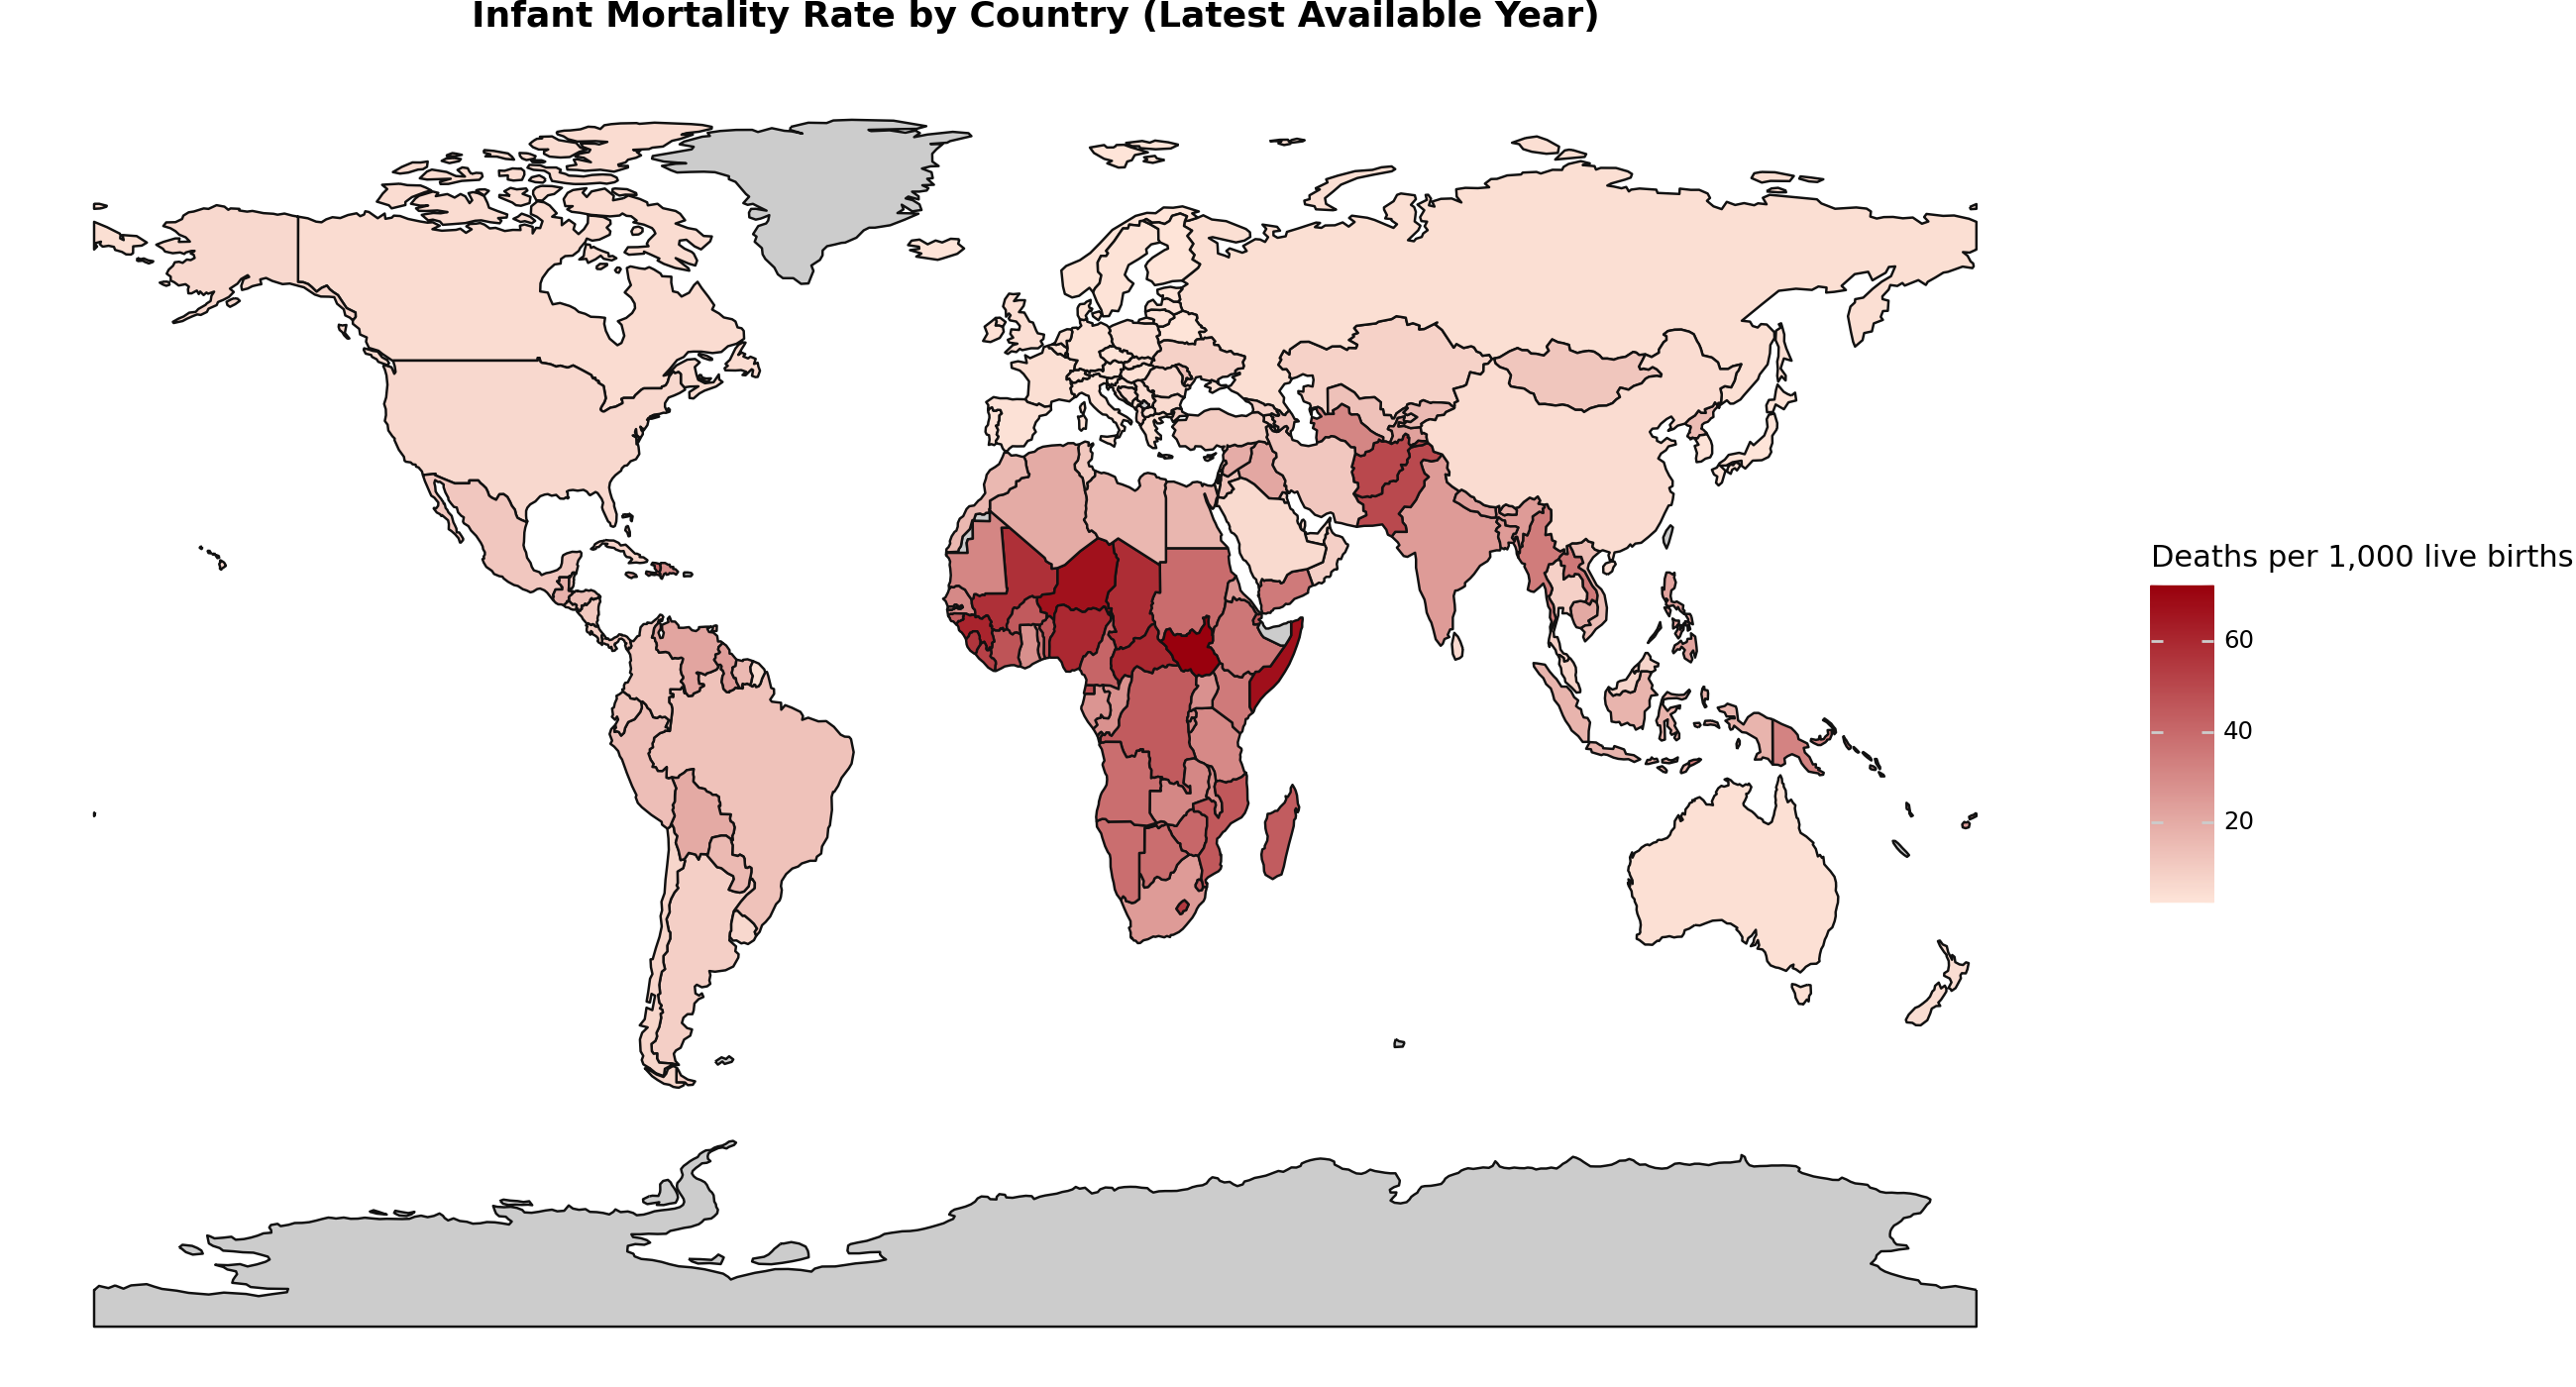

In [17]:
#| label: fig-worldmap
#| fig-cap: "Global distribution of infant mortality rates (latest available year per country). Grey = no data."
#| fig-width: 13
#| fig-height: 7

# --- Data transformation ---
# Latest obs_value per country (sorted by time_period within group)
map_data = (
    indicator1
    .filter(pl.col('sex') == 'Total')
    .group_by(['alpha_3_code', 'country'])
    .agg([
        pl.col('obs_value').sort_by('time_period').last().alias('infant_mortality'),
        pl.col('time_period').max().alias('year')
    ])
)

# --- Load world geometry ---
# Uses local .gpkg if available, otherwise downloads from Natural Earth.
# This makes it work both locally and in Google Colab.
GPKG_PATH = 'ne_110m_countries.gpkg'
NE_URL    = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'

if os.path.exists(GPKG_PATH):
    world = gpd.read_file(GPKG_PATH)
else:
    print('Shapefile not found locally — downloading from Natural Earth...')
    world = gpd.read_file(NE_URL)
    world.to_file(GPKG_PATH, driver='GPKG')   # cache for next run
    print('Download complete and cached.')

# Merge geometry with UNICEF data on ISO alpha-3 code
world_merged = world.merge(
    map_data.to_pandas(),
    left_on='ISO_A3_EH',
    right_on='alpha_3_code',
    how='left'
)

# --- Visualisation ---
(
    ggplot(world_merged)
    + geom_map(aes(fill='infant_mortality'))
    + scale_fill_gradient(
        low='#fee5d9',
        high='#99000d',
        na_value='#cccccc',
        name='Deaths per 1,000 live births'
    )
    + labs(title='Infant Mortality Rate by Country (Latest Available Year)')
    + theme_void()
    + theme(
        figure_size=(13, 7),
        plot_title=element_text(size=13, face='bold', ha='center')
    )
)


## 2. Has It Gotten Better Over Time?

Looking at a small group of countries enables indetifying the trends better. Six countries were picked for this reason to cover a range of income levels and regions:

| Country | Profile |
|---|---|
| **Afghanistan** & **Nigeria** | Low-income, high burden |
| **India** & **Brazil** | Middle-income, large populations |
| **Ireland** & **United States** | High-income, low mortality |

Trends show that every country here has improved since 1960. Ireland and the States have gotten their rates down to nearly zero by the 1980s and have stayed stagnant since.

On the other hand, Afghanistan and Nigeria are still lacking behind the other countries. This issue prevails even today. Afghanistan in particular has struggled, due to its years of conflict and instability. This has made it difficult to build or maintain any kind of consistent healthcare system within the country.

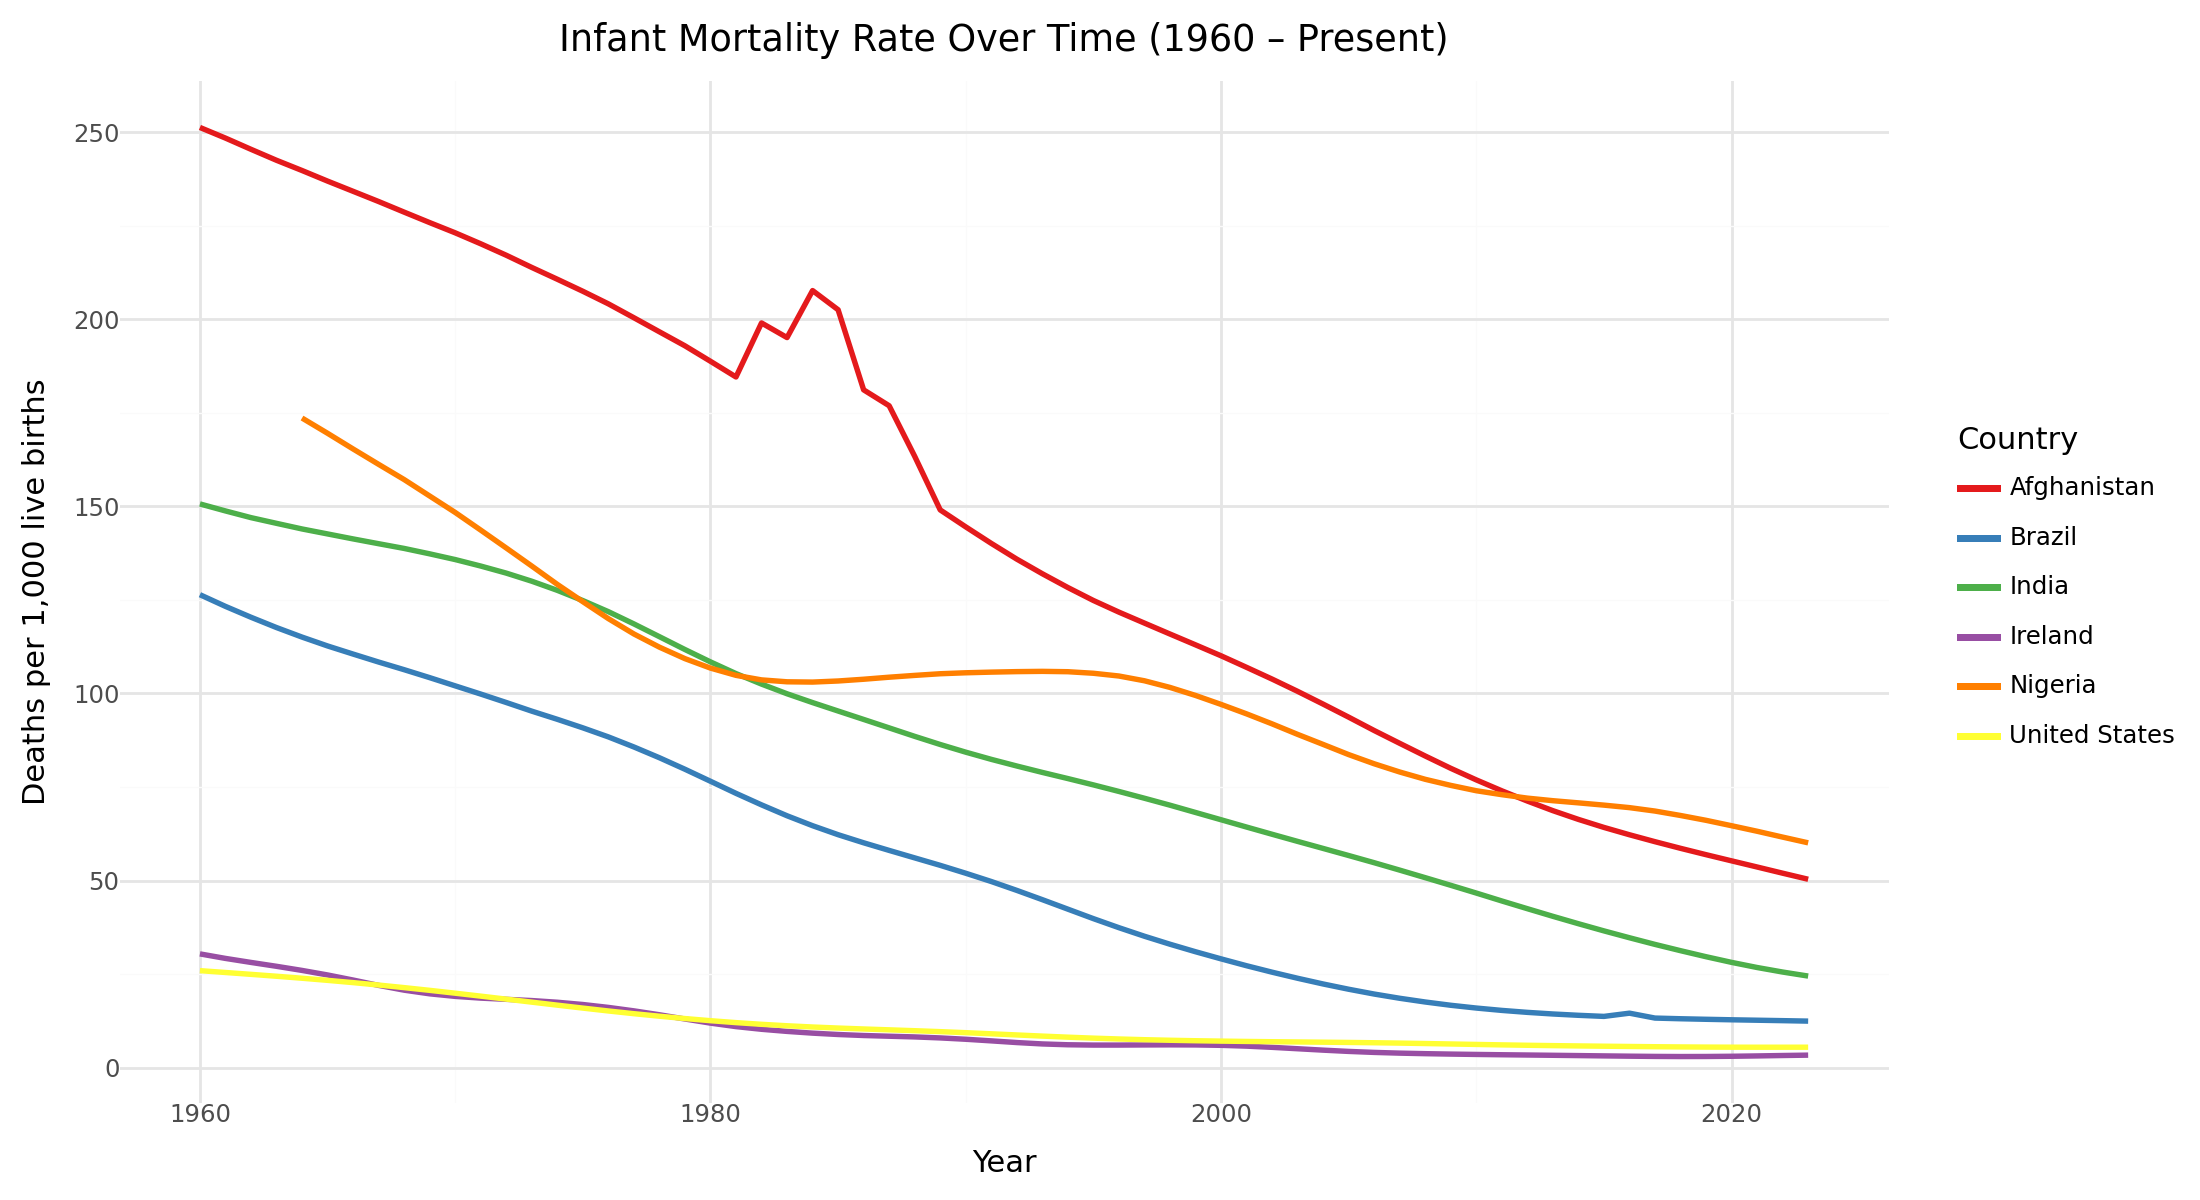

In [18]:
#| label: fig-timeseries
#| fig-cap: "Infant mortality rate from 1960 to present for six countries spanning different income levels and regions."
#| fig-width: 11
#| fig-height: 6

# --- Data transformation ---
selected_codes = ['AFG', 'NGA', 'IND', 'BRA', 'IRL', 'USA']

ts_data = (
    indicator1
    .filter(pl.col('sex') == 'Total')
    .filter(pl.col('alpha_3_code').is_in(selected_codes))
    .filter(pl.col('time_period') >= 1960)
    .select(['country', 'time_period', 'obs_value'])
    .sort('time_period')
    .to_pandas()
)

# --- Visualisation ---
(
    ggplot(ts_data, aes(x='time_period', y='obs_value', color='country'))
    + geom_line(size=1.1)
    + scale_color_brewer(type='qual', palette='Set1', name='Country')
    + labs(
        title='Infant Mortality Rate Over Time (1960 – Present)',
        x='Year',
        y='Deaths per 1,000 live births'
    )
    + theme_minimal()
    + theme(figure_size=(11, 6))
)

## 3. Does a Country's Wealth Affect Infant Mortality?

The scatter plot shows relationship between GDP per capita and infant mortality in 2020. Each dot respresents a country, and the red line represents a linear regression showing the overall trend.

The pattern shows an evident connection between wealthier countries and low infant mortality rates. Therefore more money results to better hospitals,  higher number of healthcare workers, cleaner water, and sanitation facilities.

However, GDP is not the only indicator.  Some countries do noticeably better or worse than other countries even at similar income levels, suggesting that how governments choose to spend matters as much as how much they have.

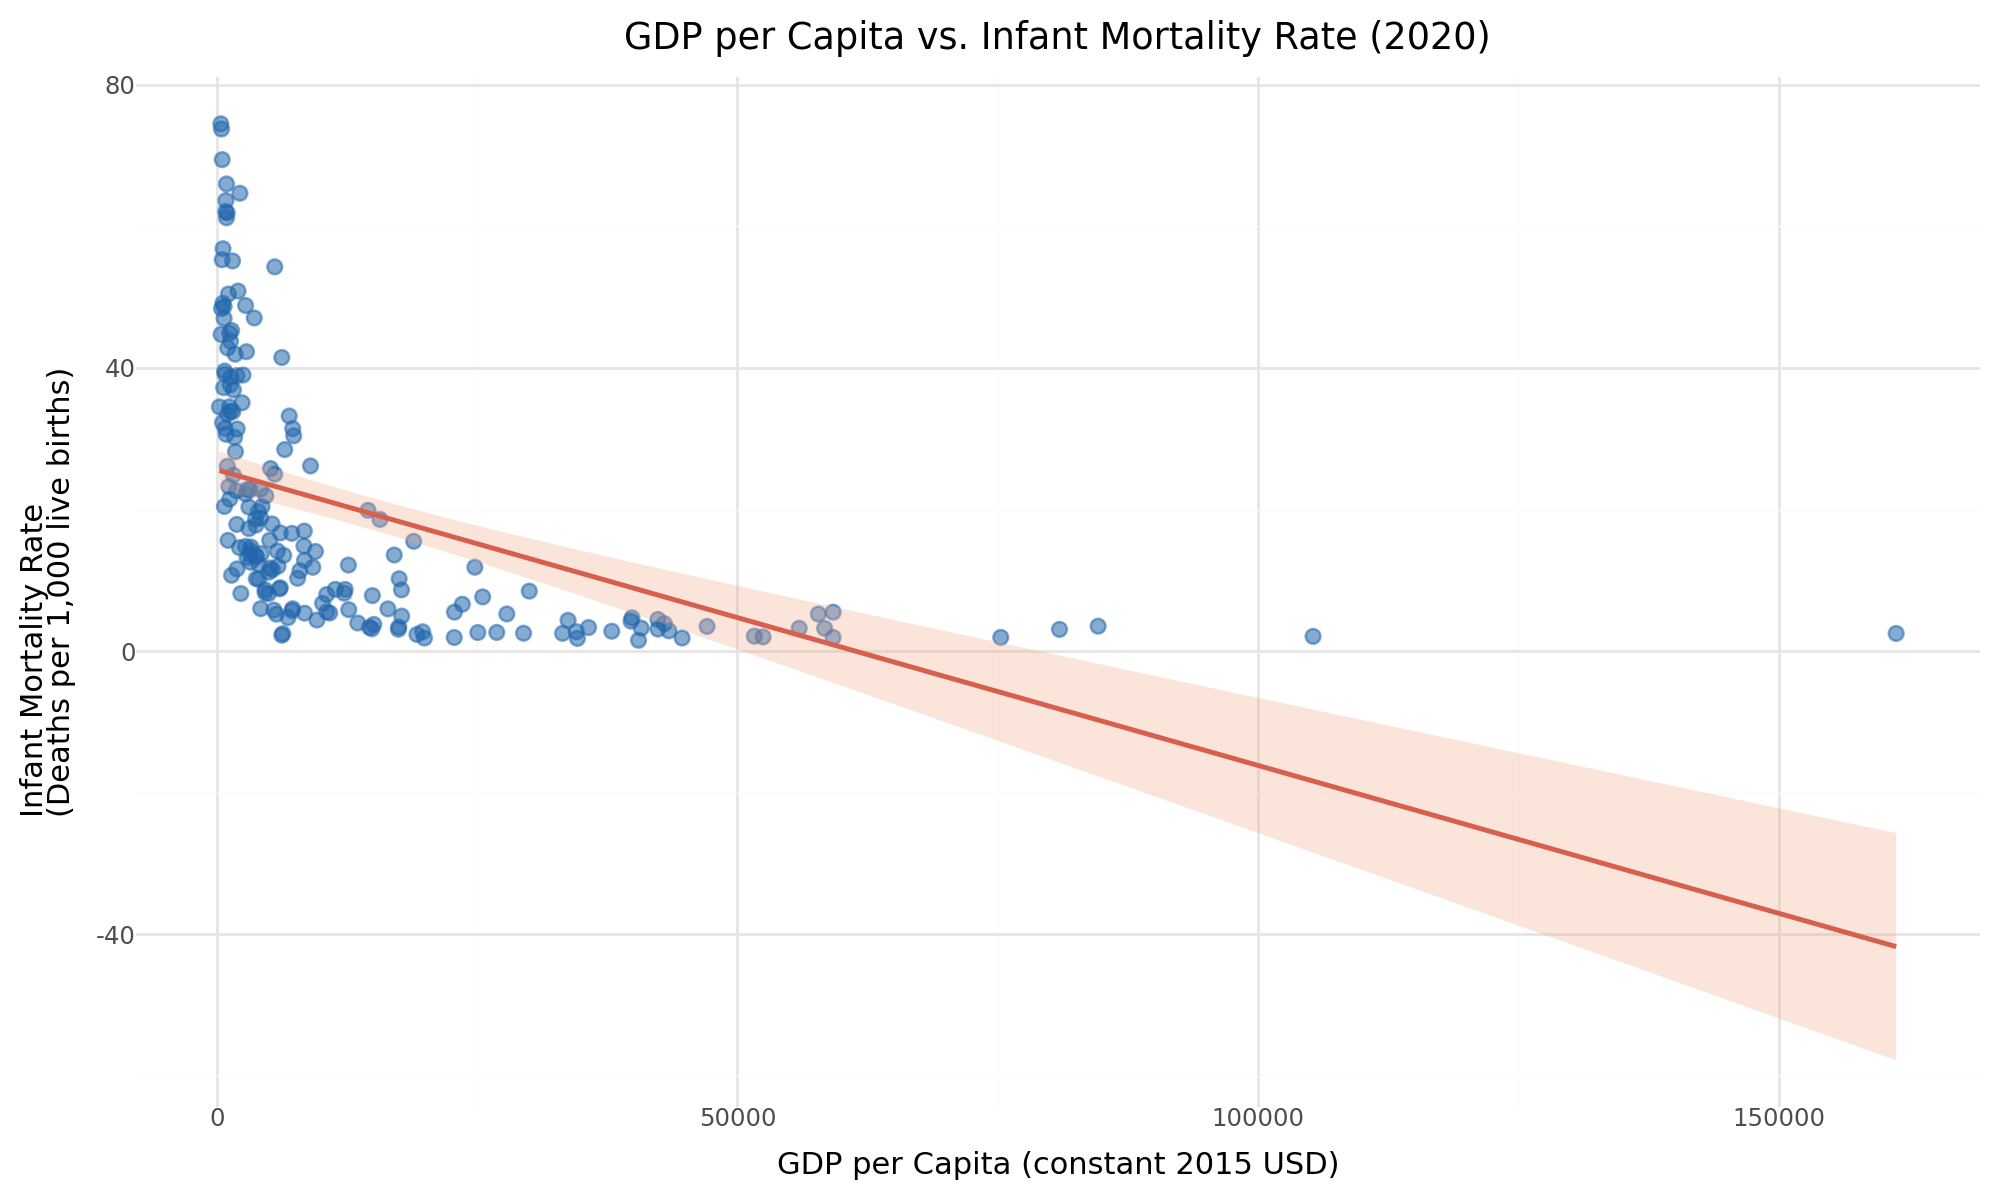

In [19]:
#| label: fig-scatter
#| fig-cap: "Each dot represents one country (2020). The regression line confirms the strong inverse relationship between national wealth and infant mortality."
#| fig-width: 10
#| fig-height: 6

# --- Data transformation ---
# Indicator 1: Total sex, year 2020
ind1_2020 = (
    indicator1
    .filter((pl.col('sex') == 'Total') & (pl.col('time_period') == 2020))
    .select([
        pl.col('alpha_3_code'),
        pl.col('obs_value').alias('infant_mortality')
    ])
)

# Metadata: year 2020, GDP per capita
meta_2020 = (
    metadata
    .filter(pl.col('year') == 2020)
    .select([
        pl.col('alpha_3_code'),
        pl.col('GDP per capita (constant 2015 US$)').alias('gdp_per_capita')
    ])
)

# Join and remove nulls
scatter_data = (
    ind1_2020
    .join(meta_2020, on='alpha_3_code', how='inner')
    .drop_nulls()
    .to_pandas()
)

# --- Visualisation ---
(
    ggplot(scatter_data, aes(x='gdp_per_capita', y='infant_mortality'))
    + geom_point(alpha=0.55, color='#2166ac', size=2.5)
    + stat_smooth(method='lm', color='#d6604d', fill='#f4a582', alpha=0.3)
    + labs(
        title='GDP per Capita vs. Infant Mortality Rate (2020)',
        x='GDP per Capita (constant 2015 USD)',
        y='Infant Mortality Rate\n(Deaths per 1,000 live births)'
    )
    + theme_minimal()
    + theme(figure_size=(10, 6))
)

## 4. Which Countries Have the Lowest Vaccination Rates?

Vaccines are considered one of the most cost-effective tools in public healthcare. Polio that led to paralyses of hundreds of thousands of children every year, is nearly eradicated, mainly because of vaccination campaigns that were run across the globe.

However, coverage still remains a relevant problem across the globe. The World Health Organization advices that **at least 90%** of infants should receive key vaccines to keep communities protected. The chart below shows the 20 countries that are furthest from hitting those target. This is based on the most recent data for the second dose of the polio vaccine.

Some of these countries are below 30%, meaning that majority of babies are going unvaccinated. Most of them are dealing with conflict, very weak healthcare systems, or both.

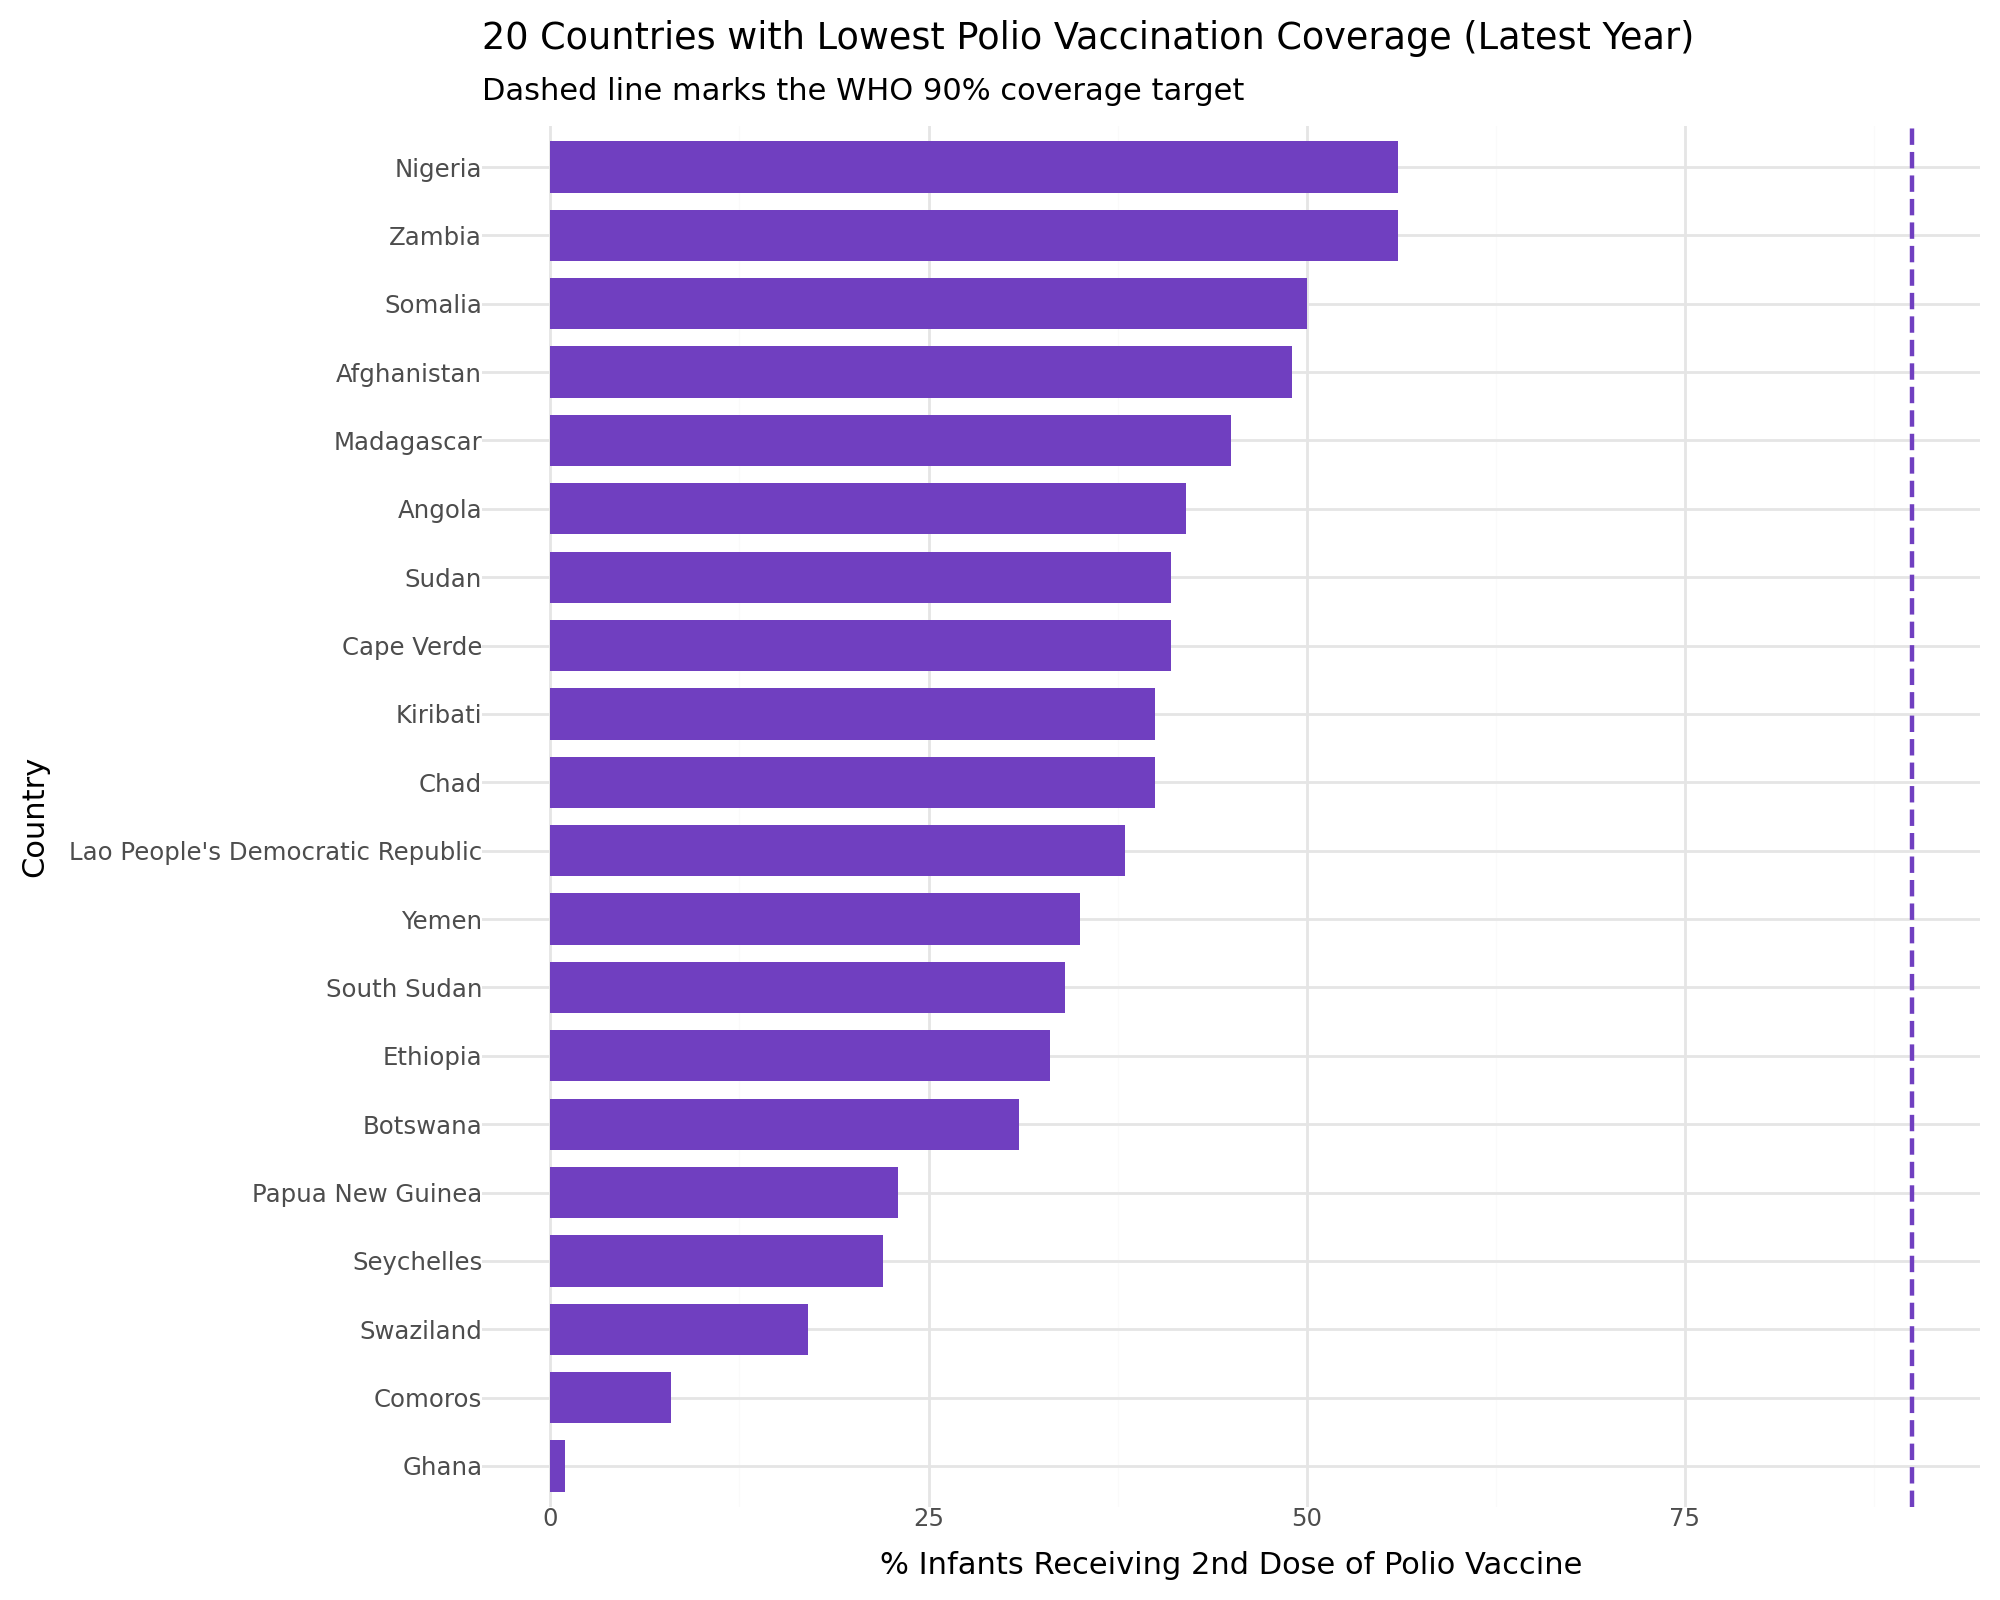

In [20]:
#| label: fig-barchart
#| fig-cap: "Countries with the 20 lowest polio vaccination rates (most recent UNICEF data, 2021–2024). Dashed line = WHO 90% coverage target."
#| fig-width: 10
#| fig-height: 8

# --- Data transformation ---
# Latest vaccination rate per country (sort by year descending, take first)
bar_data = (
    indicator2
    .filter(pl.col('sex') == 'Total')
    .group_by(['country', 'alpha_3_code'])
    .agg(
        pl.col('obs_value').sort_by('time_period').last().alias('vax_rate')
    )
    .sort('vax_rate')
    .head(20)
    .to_pandas()
)

# Order countries for horizontal bar chart (ascending vax_rate = lowest at bottom)
bar_data = bar_data.sort_values('vax_rate')
bar_data['country'] = pd.Categorical(
    bar_data['country'],
    categories=bar_data['country'].tolist(),
    ordered=True
)

# --- Visualisation ---
(
    ggplot(bar_data, aes(x='country', y='vax_rate'))
    + geom_bar(stat='identity', fill='#703fc0', width=0.75)
    + geom_hline(yintercept=90, linetype='dashed', color='#703fc0', size=0.9)
    + coord_flip()
    + labs(
        title='20 Countries with Lowest Polio Vaccination Coverage (Latest Year)',
        subtitle='Dashed line marks the WHO 90% coverage target',
        x='Country',
        y='% Infants Receiving 2nd Dose of Polio Vaccine'
    )
    + theme_minimal()
    + theme(figure_size=(10, 8))
)

## Conclusion

The four charts above can be summzarized:

1. **The problem is concentrated**: infant mortality is relatively high in Sub-Saharan Africa regions and parts of South Asia, while wealthier countries like USA or European states have largely moved past these national issues.
2. **Progress has been made**: While some country has made more progress than others, the time-series has improved significantly since 1960, depciting that change is possible when investment is made.
3. **Wealth and choices matter equally**: GDP per capita strongly predicts infant survival, but some countries outperform their income level, showing that policy decisions contribute towards erdacting these global issues.
4. **Vaccination gaps are still too large**: many countries are nowhere near the 90% WHO target, leaving millions of children at unnecessary risk, even today.

Infant mortality is not just a health problem, bt is ties to something deeper. It  represents poverty, conflict, and inequality. Addressing it properly means investing not just in vaccines and hospitals, but in the wider conditions that allow healthcare to actually function, in a way that actually makes a difference.

---

*Data source: UNICEF — unicef_indicator_1.csv, unicef_indicator_2.csv, unicef_metadata.csv*